# Choosing output distributions and deriving loss functions

This supplementary notebook expands Figure 5.11 from [Chapter 5: Loss functions](../chapter-05-loss-functions.pdf). Its central purpose is to explain **why the type of target variable determines the probability distribution, and why that distribution determines the loss function**.

The core pipeline is

$$
x_i
\longrightarrow f[x_i,\phi]=\theta_i
\longrightarrow p(y_i\mid\theta_i)
\longrightarrow -\log p(y_i\mid\theta_i).
$$

Here, $\phi$ denotes the shared neural-network parameters, while $\theta_i$ denotes the parameters of the output distribution predicted for input $x_i$.

> **Suggested first pass:** Read Topics 0–3 and the final checklist first. Topics 4–5 are a reference for less common distributions and can be revisited when a task requires them.


## Topic 0 — Beginner prerequisites and reading guide


### 0.1 You are not expected to master every distribution at once

This notebook contains both everyday losses and advanced reference material. Use these levels:

| Level | Distributions | What to learn now |
|---|---|---|
| Core | Normal, Bernoulli, categorical | Understand the target type, network output, and resulting loss |
| Useful next | Poisson, Laplace, exponential, gamma, beta, von Mises | Understand when the target domain requires them |
| Advanced reference | Student's $t$, Gaussian mixtures, multivariate normal, Plackett–Luce | Recognize their purpose; revisit the full formulas when needed |

For a first pass, it is enough to answer three questions for each distribution:

1. Which values can the target take?
2. Which parameter or parameters does the network predict?
3. What kind of mistakes does the resulting loss penalize?

You do not need to memorize normalization constants, gamma functions, covariance formulas, or special functions.


### 0.2 Target variables, observations, and examples

A **variable** is a quantity that can take different values. In supervised learning, the target variable is denoted by $y$.

| Prediction problem | Target $y$ | One observed value |
|---|---|---|
| House-price regression | Sale price | $310{,}000$ USD |
| Binary classification | Rain or no rain | $1$ for rain |
| Multiclass classification | Animal category | Cat |
| Count prediction | Number of pedestrians | $7$ |
| Direction prediction | Wind angle | $1.2$ radians |

A training dataset contains observed pairs

$$
(x_1,y_1),(x_2,y_2),\ldots,(x_I,y_I).
$$

The input $x_i$ contains information used for prediction. The target $y_i$ is what was actually observed for that example.


### 0.3 Discrete probabilities versus continuous densities

A **discrete** target has separated possible values, such as

$$
y\in\{0,1,2,\ldots\}.
$$

Labels and counts are discrete. A discrete distribution assigns an ordinary probability to each possible value.

A **continuous** target can vary smoothly over an interval, such as

$$
y\in\mathbb{R}.
$$

Temperature, price, and duration are continuous. A continuous distribution uses a **probability density**. Density describes how concentrated probability is near a value; it is not the probability of observing that exact point.

Chapter 5 often writes $\Pr(y\mid\theta)$ for both cases. Read it as probability when $y$ is discrete and probability density when $y$ is continuous.

For deriving negative log-likelihood, both are used in the same way: evaluate the distribution at the observed target, then take the negative logarithm.


### 0.4 What are a distribution and its parameters?

A **probability distribution** is a rule that assigns probability or density across the legal values of a variable.

A **parameter** controls the distribution's shape or location.

| Distribution | Parameters | What they control |
|---|---|---|
| Normal | $\mu,\sigma^2$ | Center and spread |
| Bernoulli | $\lambda$ | Probability of label $1$ |
| Categorical | $\lambda_1,\ldots,\lambda_K$ | Probability of each class |
| Poisson | $\lambda$ | Expected event count |

The symbol $\theta$ is a generic container for whichever parameters the selected distribution requires. The neural network computes these parameters from the input:

$$
\theta_i=f[x_i,\phi].
$$

The network parameters $\phi$ are shared across the dataset. The predicted distribution parameters $\theta_i$ can change from one input to another.


### 0.5 Why does negative log-likelihood become a loss?

Suppose the model assigns score $p$ to the observed target. The negative-log loss is

$$
\ell=-\log(p).
$$

| Score assigned to the observed target $p$ | Loss $-\log(p)$ | Interpretation |
|---:|---:|---|
| $0.90$ | Approximately $0.11$ | Small loss: the observation was expected |
| $0.50$ | Approximately $0.69$ | Moderate loss |
| $0.10$ | Approximately $2.30$ | Large loss: the observation was surprising |
| $0.01$ | Approximately $4.61$ | Very large loss |

The negative logarithm gives the desired behavior:

- high score for the observed target $\Rightarrow$ low loss;
- low score for the observed target $\Rightarrow$ high loss.

During training, the model changes $\phi$ so that observed targets receive larger probability or density under the predicted distributions.


### 0.6 Logarithm rules used in the derivations

The notebook uses a small set of logarithm rules:

| Rule | Meaning |
|---|---|
| $\log(ab)=\log a+\log b$ | A product becomes a sum |
| $\log(a/b)=\log a-\log b$ | A quotient becomes a difference |
| $\log(a^r)=r\log a$ | An exponent moves in front |
| $\log(\exp a)=a$ | Logarithm cancels exponential |

For example,

$$
-\log\left[\lambda^y(1-\lambda)^{1-y}\right]
=-y\log\lambda-(1-y)\log(1-\lambda).
$$

When a derivation jumps between lines, look for a product, quotient, power, or exponential. Usually one of these four rules explains the step.


### 0.7 Symbol and function cheat sheet

Some distributions require notation that is not essential on a first pass:

| Symbol | Beginner meaning |
|---|---|
| $|y-\mu|$ | Absolute distance from $y$ to $\mu$ |
| $y!$ | Factorial: $y(y-1)\cdots2\cdot1$ |
| $\Gamma(a)$ | Gamma function; a generalization of factorial |
| $I_0(\kappa)$ | A normalization function used by von Mises |
| $\Sigma$ | Covariance matrix describing multivariate spread and correlation |
| $|\Sigma|$ | Determinant of the covariance matrix |
| $\Sigma^{-1}$ | Inverse covariance matrix |
| $(\mathbf{y}-\boldsymbol{\mu})^T$ | Transpose of a vector difference |
| $C$ | A term treated as constant in the current derivation |

These symbols ensure that a distribution is mathematically valid and normalized. You may treat $\Gamma$, $I_0$, determinants, and matrix inverses as supplied operations until later study.

The important beginner question is: **which terms depend on the network prediction, and how do they penalize an incorrect prediction?**


### 0.8 How to read each distribution section

Each distribution section follows the same pattern:

1. **Use when:** identifies the target type and modeling assumption.
2. **Distribution:** states the probability or density assigned to an observed $y$.
3. **Network output:** identifies which parameters are predicted from $x$.
4. **Negative logarithm:** converts the distribution into a loss.
5. **Simplification:** removes only terms that cannot affect the fitted network parameters.
6. **Interpretation:** explains what kind of prediction error is penalized.

If an advanced formula feels overwhelming, first ignore its normalization constants and locate:

- the observed target $y$;
- the model prediction, such as $\mu$ or $\lambda$;
- the part that measures disagreement between them.

Return to the remaining terms when you need the full probabilistic interpretation.


## Topic 1 — The distribution-to-loss recipe


### 1.1 The central idea: the network predicts a distribution

A neural network does not have to predict the target $y$ directly. It can predict the parameters $\theta$ of a probability distribution over possible values of $y$.

Examples:

| Task | Network predicts | Distribution describes |
|---|---|---|
| Real-valued regression | Mean $\mu$ and perhaps variance $\sigma^2$ | Plausible numerical targets |
| Binary classification | Probability $\lambda$ | Plausibility of labels $0$ and $1$ |
| Multiclass classification | Probabilities $\lambda_1,\ldots,\lambda_K$ | Plausibility of each class |
| Count prediction | Rate $\lambda$ | Plausibility of counts $0,1,2,\ldots$ |

Once the distribution has been selected, one observed target contributes the negative log-likelihood

$$
\ell_i(\phi)=-\log p\left(y_i\mid\theta_i\right),
\qquad
\theta_i=f[x_i,\phi].
$$

The complete dataset loss is

$$
\mathcal{L}[\phi]
=-\sum_{i=1}^{I}\log p\left(y_i\mid f[x_i,\phi]\right).
$$

The loss is therefore not chosen independently of the model's output distribution. It is obtained by taking the negative logarithm of that distribution evaluated at the observed target.


### 1.2 The five-step procedure

For a new prediction problem, follow this sequence:

1. **Identify the target domain:** What values can $y$ legally take?
2. **Choose a plausible distribution:** What shapes, noise, tails, or dependencies should be possible?
3. **Choose distribution parameters:** Which parameters must the network predict?
4. **Enforce parameter constraints:** How will unrestricted network outputs become valid parameters?
5. **Derive the loss:** Substitute the predicted parameters into $-\log p(y\mid\theta)$.

A short example for counts:

1. Pedestrian count: $y\in\{0,1,2,\ldots\}$.
2. Choose a Poisson distribution.
3. The network predicts the positive rate $\lambda(x)$.
4. Apply a positive transform such as softplus to the raw network output.
5. Substitute $\lambda(x)$ into the Poisson negative log-likelihood.

The process starts with the **meaning and legal values of the target**, not with a favorite loss function.


### 1.3 First choose by domain, then choose by shape

The **domain**, also called the **support**, is the set of values to which a distribution can assign probability or density.

A distribution is immediately unsuitable if its support excludes legal targets:

- A normal distribution permits negative values, so it may be inappropriate for strictly positive durations.
- A Bernoulli distribution only supports $0$ and $1$, so it cannot represent a count of $7$.
- A beta distribution supports values between $0$ and $1$, so it is suitable for proportions but not arbitrary real values.

Matching the support is necessary but not sufficient. Several distributions can share the same support while making different assumptions:

| Same target domain | Possible choices | Different assumption |
|---|---|---|
| $y\in\mathbb{R}$ | Normal | Symmetric, relatively light-tailed noise |
| $y\in\mathbb{R}$ | Laplace | Sharper peak and heavier tails |
| $y\in\mathbb{R}$ | Student's $t$ | Very heavy tails and robustness to outliers |
| $y\in\mathbb{R}$ | Gaussian mixture | Several plausible modes or outcomes |

So the decision has two stages:

> **Domain asks what is possible. Shape asks what is plausible.**


### 1.4 The network must produce valid distribution parameters

Raw neural-network outputs can be any real numbers. Distribution parameters often have constraints, so a transformation is required.

| Required parameter | Constraint | Common transformation |
|---|---|---|
| Normal mean $\mu$ | Any real number | Identity |
| Standard deviation $\sigma$ | Positive | Softplus or exponential |
| Bernoulli probability $\lambda$ | Between $0$ and $1$ | Sigmoid |
| Categorical probabilities $\lambda_k$ | Nonnegative and sum to $1$ | Softmax |
| Poisson rate $\lambda$ | Positive | Softplus or exponential |
| Mixture weights $\pi_m$ | Nonnegative and sum to $1$ | Softmax |
| Covariance matrix $\Sigma$ | Positive definite | Structured parameterization such as a Cholesky factor |

For example, if the network produces an unrestricted scalar $a(x)$ for a Poisson rate, use

$$
\lambda(x)=\operatorname{softplus}(a(x))>0.
$$

The transform is part of the probabilistic model. Without it, the network could produce invalid distribution parameters.


## Topic 2 — A practical decision map for Figure 5.11


### 2.1 Expanded distribution-selection table

| Target variable | Legal values | Typical distribution | Network predicts | Common loss |
|---|---|---|---|---|
| Unbounded measurement | $y\in\mathbb{R}$ | Normal | Mean, optionally variance | Gaussian NLL; least squares if variance is fixed |
| Real value with outliers | $y\in\mathbb{R}$ | Laplace or Student's $t$ | Location and scale | Laplace or Student's $t$ NLL |
| Several plausible real outcomes | $y\in\mathbb{R}$ | Gaussian mixture | Weights, means, scales | Mixture NLL |
| Positive duration or magnitude | $y>0$ | Exponential or gamma | Positive rate; or shape and rate | Exponential or gamma NLL |
| Proportion | $0<y<1$ | Beta | Two positive shape parameters | Beta NLL |
| Several correlated real outputs | $\mathbf{y}\in\mathbb{R}^D$ | Multivariate normal | Mean vector and covariance | Multivariate Gaussian NLL |
| Direction or angle | $y\in(-\pi,\pi]$ | von Mises | Mean direction and concentration | von Mises NLL |
| Binary label | $y\in\{0,1\}$ | Bernoulli | One probability or logit | Binary cross-entropy |
| One of $K$ classes | $y\in\{1,\ldots,K\}$ | Categorical | $K$ probabilities or logits | Multiclass cross-entropy |
| Event count | $y\in\{0,1,2,\ldots\}$ | Poisson | Positive rate | Poisson NLL |
| Ranking | A permutation | Plackett–Luce | One score per item | Ranking NLL |

This table proposes starting points, not automatic final answers. Real data may violate the chosen assumptions, so distribution choice should be checked empirically.


### 2.2 The visual pipeline: connect the real target to the loss

Every row in the selection table should be read as one complete chain:

$$
\text{real problem}
\longrightarrow
\text{target and legal values}
\longrightarrow
\text{distribution shape}
\longrightarrow
\text{network parameters}
\longrightarrow
\text{negative-log loss}.
$$

For example:

$$
\text{pedestrians per minute}
\longrightarrow y\in\{0,1,2,\ldots\}
\longrightarrow \text{Poisson}
\longrightarrow \lambda(x)>0
\longrightarrow \text{Poisson NLL}.
$$

The following galleries turn every row of the table into a concrete target and a plot. The vertical axis of a continuous plot is **density**, while the vertical axis of a discrete bar chart is **probability**.


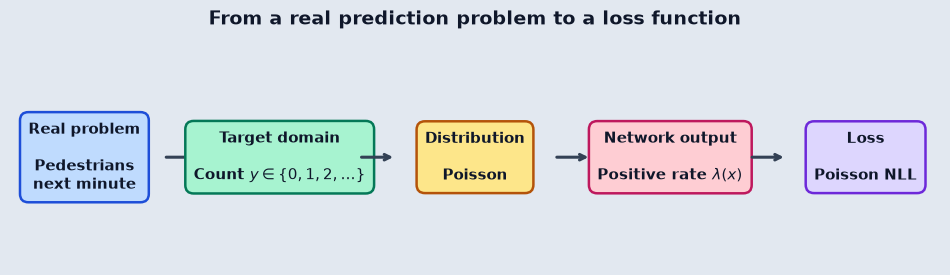

In [1]:
import matplotlib.pyplot as plt

steps = [
    ("Real problem", "Pedestrians\nnext minute"),
    ("Target domain", r"Count $y\in\{0,1,2,\ldots\}$"),
    ("Distribution", "Poisson"),
    ("Network output", r"Positive rate $\lambda(x)$"),
    ("Loss", "Poisson NLL"),
]

# Explicit colors keep the diagram readable in both light and dark notebook themes.
figure_background = "#e2e8f0"
text_color = "#0f172a"
box_colors = ["#bfdbfe", "#a7f3d0", "#fde68a", "#fecdd3", "#ddd6fe"]
edge_colors = ["#1d4ed8", "#047857", "#b45309", "#be185d", "#6d28d9"]

fig, ax = plt.subplots(figsize=(12, 2.8), facecolor=figure_background)
ax.set_facecolor(figure_background)
ax.axis("off")
xs = [0.08, 0.29, 0.50, 0.71, 0.92]
for index, ((title, body), x_pos) in enumerate(zip(steps, xs)):
    ax.text(
        x_pos,
        0.5,
        f"{title}\n\n{body}",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=text_color,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor=box_colors[index],
            edgecolor=edge_colors[index],
            linewidth=1.8,
        ),
        transform=ax.transAxes,
    )
    if index < len(steps) - 1:
        ax.annotate(
            "",
            xy=(xs[index + 1] - 0.085, 0.5),
            xytext=(x_pos + 0.085, 0.5),
            arrowprops=dict(arrowstyle="->", lw=2.2, color="#334155"),
            xycoords=ax.transAxes,
        )
ax.set_title(
    "From a real prediction problem to a loss function",
    fontsize=14,
    fontweight="bold",
    color=text_color,
    pad=18,
)
plt.show()


### 2.3 Unbounded real targets: normal, robust, and multimodal models

These distributions all allow $y\in\mathbb{R}$, but they describe different shapes.

| Real problem | Target | Distribution | Network predicts | Loss |
|---|---|---|---|---|
| Predict tomorrow's temperature | Temperature | Normal | Mean and perhaps variance | Gaussian NLL; squared error if variance is fixed |
| Predict a sensor value with occasional extreme errors | Measurement | Laplace or Student's $t$ | Location and scale | Robust NLL |
| Predict travel time when either a fast or slow route may occur | Travel time after centering | Gaussian mixture | Weights, means, scales | Mixture NLL |

Read the plots as follows:

- **Normal:** one ordinary symmetric bell.
- **Laplace or Student's $t$:** more density remains far from the center, so outliers are less surprising.
- **Gaussian mixture:** several peaks represent several plausible outcomes.


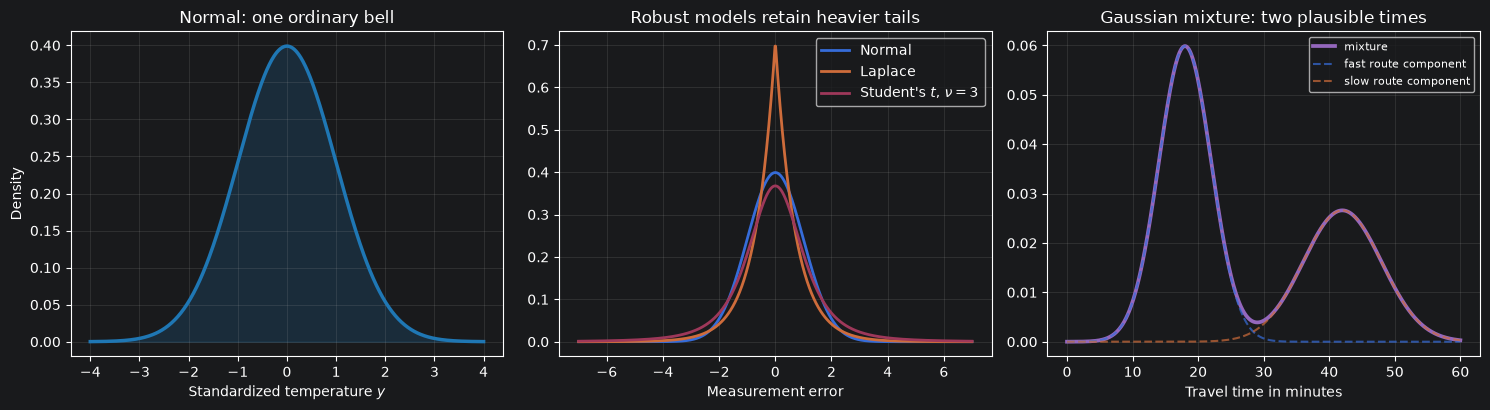

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import laplace, norm, t

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# Normal: one central temperature prediction.
y = np.linspace(-4, 4, 500)
axes[0].plot(y, norm.pdf(y, loc=0, scale=1), linewidth=2.5, color="tab:blue")
axes[0].fill_between(y, norm.pdf(y), alpha=0.2, color="tab:blue")
axes[0].set_title("Normal: one ordinary bell")
axes[0].set_xlabel(r"Standardized temperature $y$")
axes[0].set_ylabel("Density")

# Robust alternatives: compare their tails with a normal.
y = np.linspace(-7, 7, 700)
axes[1].plot(y, norm.pdf(y), label="Normal", linewidth=2)
axes[1].plot(y, laplace.pdf(y, scale=1 / np.sqrt(2)), label="Laplace", linewidth=2)
axes[1].plot(y, t.pdf(y, df=3) / 1.0, label=r"Student's $t$, $\nu=3$", linewidth=2)
axes[1].set_title("Robust models retain heavier tails")
axes[1].set_xlabel("Measurement error")
axes[1].legend()

# Mixture: travel time has a fast and slow mode.
y = np.linspace(0, 60, 700)
fast = norm.pdf(y, loc=18, scale=4)
slow = norm.pdf(y, loc=42, scale=6)
mixture = 0.6 * fast + 0.4 * slow
axes[2].plot(y, mixture, linewidth=2.7, color="tab:purple", label="mixture")
axes[2].plot(y, 0.6 * fast, "--", alpha=0.7, label="fast route component")
axes[2].plot(y, 0.4 * slow, "--", alpha=0.7, label="slow route component")
axes[2].set_title("Gaussian mixture: two plausible times")
axes[2].set_xlabel("Travel time in minutes")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


### 2.4 Positive and bounded targets: exponential, gamma, and beta

| Real problem | Target domain | Distribution | Network predicts | Loss |
|---|---|---|---|---|
| Time until the next arrival, with short waits most common | $y\geq0$ | Exponential | Positive rate $\lambda$ | Exponential NLL |
| Total time for several stages, clustered away from zero | $y>0$ | Gamma | Positive shape $\alpha$ and rate $\beta$ | Gamma NLL |
| Fraction of a task completed | $0<y<1$ | Beta | Positive shapes $\alpha,\beta$ | Beta NLL |

The exponential and gamma distributions allow positive values. The beta distribution is trapped between zero and one.

The first panel compares exponential and gamma densities with the same mean. The second shows that beta can represent very different patterns of proportions.


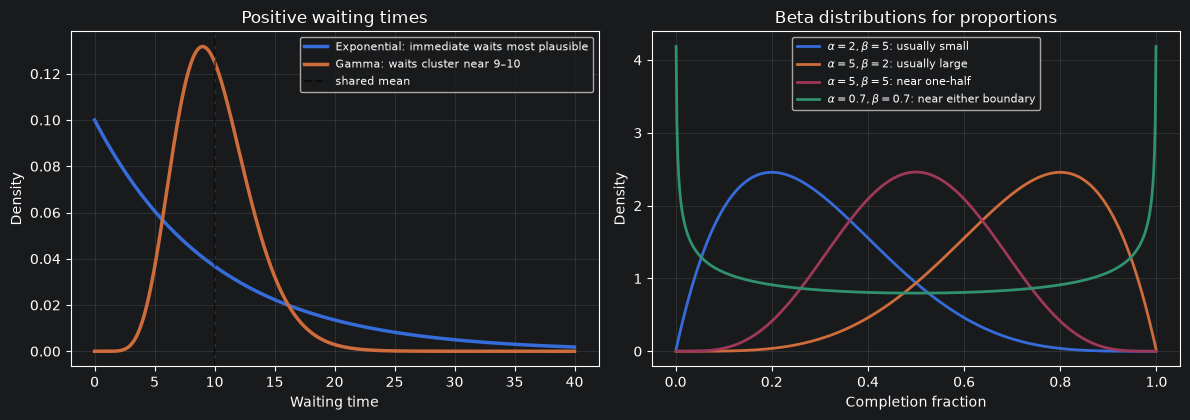

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
from scipy.stats import expon, gamma

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

# Same mean 10, different shapes.
y = np.linspace(0.001, 40, 700)
axes[0].plot(y, expon.pdf(y, scale=10), linewidth=2.5,
             label="Exponential: immediate waits most plausible")
axes[0].plot(y, gamma.pdf(y, a=10, scale=1), linewidth=2.5,
             label="Gamma: waits cluster near 9–10")
axes[0].axvline(10, color="black", linestyle="--", alpha=0.5, label="shared mean")
axes[0].set_title("Positive waiting times")
axes[0].set_xlabel("Waiting time")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# Beta shapes for proportions.
y = np.linspace(0.001, 0.999, 600)
for a, b, description in [
    (2, 5, "usually small"),
    (5, 2, "usually large"),
    (5, 5, "near one-half"),
    (0.7, 0.7, "near either boundary"),
]:
    axes[1].plot(y, beta_dist.pdf(y, a, b), linewidth=2,
                 label=fr"$\alpha={a},\beta={b}$: {description}")
axes[1].set_title("Beta distributions for proportions")
axes[1].set_xlabel("Completion fraction")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


### 2.5 Correlated vectors and circular directions

| Real problem | Target | Distribution | Network predicts | Loss |
|---|---|---|---|---|
| Predict height and weight together | $\mathbf{y}\in\mathbb{R}^2$ | Multivariate normal | Mean vector and covariance | Multivariate Gaussian NLL |
| Predict prevailing wind direction | $y\in(-\pi,\pi]$ | von Mises | Mean direction $\mu$ and concentration $\kappa$ | von Mises NLL |

A multivariate normal forms an ellipse or cloud. Its tilt represents correlation between outputs.

A von Mises distribution wraps around a circle, so directions just below $\pi$ and just above $-\pi$ remain close.


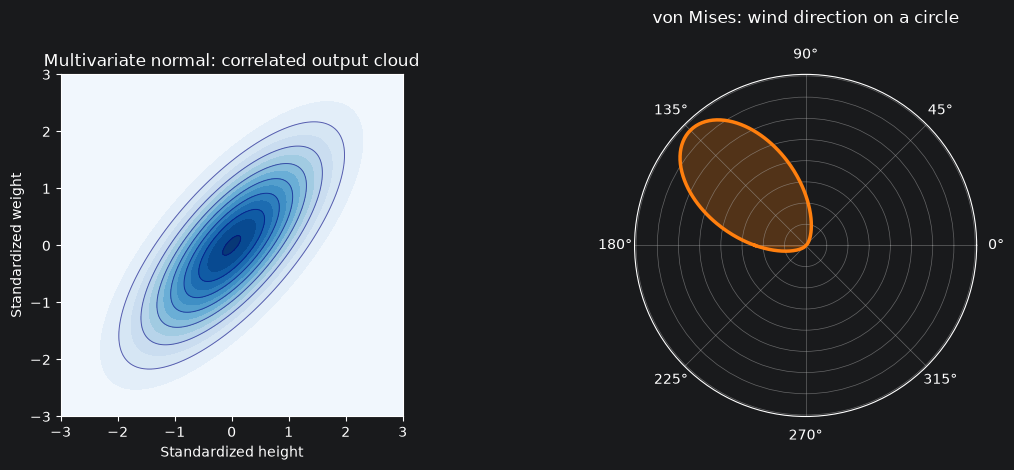

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, vonmises

fig = plt.figure(figsize=(12, 4.8))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, projection="polar")

# Correlated height and weight, standardized for illustration.
x = np.linspace(-3, 3, 220)
y = np.linspace(-3, 3, 220)
xx, yy = np.meshgrid(x, y)
positions = np.dstack((xx, yy))
covariance = np.array([[1.0, 0.8], [0.8, 1.2]])
density = multivariate_normal(mean=[0, 0], cov=covariance).pdf(positions)
ax1.contourf(xx, yy, density, levels=14, cmap="Blues")
ax1.contour(xx, yy, density, levels=7, colors="navy", linewidths=0.7, alpha=0.6)
ax1.set_title("Multivariate normal: correlated output cloud")
ax1.set_xlabel("Standardized height")
ax1.set_ylabel("Standardized weight")
ax1.set_aspect("equal")

# Circular wind direction.
theta = np.linspace(-np.pi, np.pi, 600)
density = vonmises.pdf(theta, kappa=4, loc=np.pi * 0.75)
ax2.plot(theta, density, linewidth=2.5, color="tab:orange")
ax2.fill_between(theta, 0, density, alpha=0.25, color="tab:orange")
ax2.set_title("von Mises: wind direction on a circle", pad=18)
ax2.set_yticklabels([])

fig.tight_layout()
plt.show()


### 2.6 Discrete targets: Bernoulli, categorical, and Poisson

| Real problem | Target domain | Distribution | Network predicts | Loss |
|---|---|---|---|---|
| Will it rain? | $y\in\{0,1\}$ | Bernoulli | Probability of rain | Binary cross-entropy |
| Which animal is shown? | $y\in\{1,\ldots,K\}$ | Categorical | One probability per class | Multiclass cross-entropy |
| How many pedestrians pass? | $y\in\{0,1,2,\ldots\}$ | Poisson | Positive rate | Poisson NLL |

These are drawn as bars because the possible outcomes are separated rather than continuous.

- Bernoulli has exactly two bars.
- Categorical has one bar for each class.
- Poisson has one bar for each possible count.


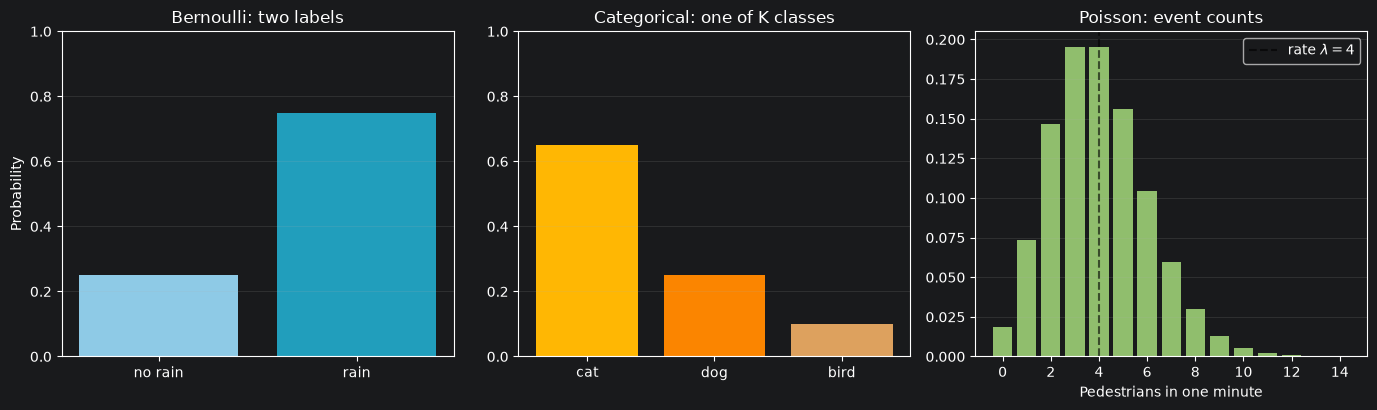

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Bernoulli rain prediction.
rain_probability = 0.75
axes[0].bar(["no rain", "rain"], [1 - rain_probability, rain_probability],
            color=["#8ecae6", "#219ebc"])
axes[0].set_title("Bernoulli: two labels")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, 1)

# Categorical animal prediction.
classes = ["cat", "dog", "bird"]
probabilities = [0.65, 0.25, 0.10]
axes[1].bar(classes, probabilities, color=["#ffb703", "#fb8500", "#dda15e"])
axes[1].set_title("Categorical: one of K classes")
axes[1].set_ylim(0, 1)

# Poisson pedestrian count.
counts = np.arange(0, 15)
rate = 4.0
axes[2].bar(counts, poisson.pmf(counts, mu=rate), color="#90be6d")
axes[2].axvline(rate, color="black", linestyle="--", alpha=0.6, label=r"rate $\lambda=4$")
axes[2].set_title("Poisson: event counts")
axes[2].set_xlabel("Pedestrians in one minute")
axes[2].legend()

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()


### 2.7 Ranking targets: Plackett–Luce as repeated selection

**Real problem:** rank three search results $A$, $B$, and $C$.

The target is not one class; it is a complete ordering such as

$$
A\succ B\succ C.
$$

Suppose the network predicts positive scores

$$
s_A=4,
\qquad s_B=2,
\qquad s_C=1.
$$

Plackett–Luce builds the ranking in stages:

1. Choose the first item from $A,B,C$ using their relative scores.
2. Remove that item.
3. Choose the next item from what remains.

For the observed ranking $A\succ B\succ C$,

$$
p(A\succ B\succ C)
=\frac{4}{4+2+1}
\times\frac{2}{2+1}
\times1
=\frac{8}{21}.
$$

The ranking NLL is the negative logarithm of this probability.


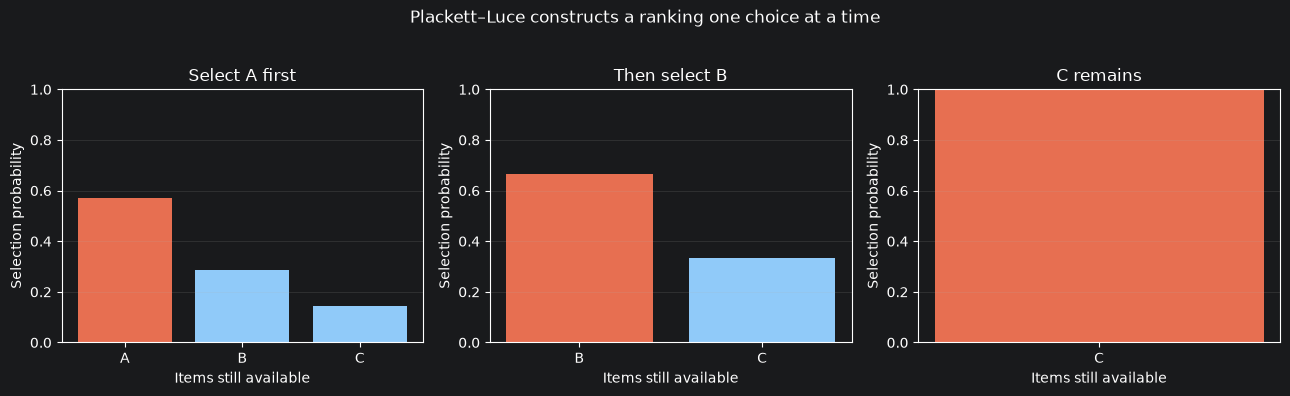

In [6]:
import numpy as np
import matplotlib.pyplot as plt

stages = [
    (['A', 'B', 'C'], [4, 2, 1], 'Select A first', 'A'),
    (['B', 'C'], [2, 1], 'Then select B', 'B'),
    (['C'], [1], 'C remains', 'C'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (items, scores, title, selected) in zip(axes, stages):
    probabilities = np.array(scores, dtype=float) / np.sum(scores)
    colors = ['#e76f51' if item == selected else '#90caf9' for item in items]
    ax.bar(items, probabilities, color=colors)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_xlabel("Items still available")
    ax.set_ylabel("Selection probability")
    ax.grid(axis="y", alpha=0.2)

fig.suptitle("Plackett–Luce constructs a ranking one choice at a time", y=1.03)
fig.tight_layout()
plt.show()


### 2.8 Link every target to its distribution and loss

When viewing a plot, say the complete chain aloud:

| Plot | Complete chain |
|---|---|
| Temperature bell | Real temperature $\rightarrow$ normal $\rightarrow$ predicted mean/variance $\rightarrow$ Gaussian NLL |
| Heavy-tailed sensor error | Real measurement with outliers $\rightarrow$ Laplace or Student's $t$ $\rightarrow$ location/scale $\rightarrow$ robust NLL |
| Two travel-time peaks | Several plausible values $\rightarrow$ Gaussian mixture $\rightarrow$ weights/means/scales $\rightarrow$ mixture NLL |
| Positive waiting time | Positive value $\rightarrow$ exponential or gamma $\rightarrow$ positive parameters $\rightarrow$ positive-value NLL |
| Completion fraction | Value between zero and one $\rightarrow$ beta $\rightarrow$ two positive shapes $\rightarrow$ beta NLL |
| Height–weight ellipse | Correlated vector $\rightarrow$ multivariate normal $\rightarrow$ mean/covariance $\rightarrow$ multivariate NLL |
| Wind circle | Angle $\rightarrow$ von Mises $\rightarrow$ direction/concentration $\rightarrow$ circular NLL |
| Rain bars | Binary label $\rightarrow$ Bernoulli $\rightarrow$ probability $\rightarrow$ BCE |
| Animal bars | One class $\rightarrow$ categorical $\rightarrow$ class probabilities $\rightarrow$ multiclass CE |
| Pedestrian bars | Count $\rightarrow$ Poisson $\rightarrow$ positive rate $\rightarrow$ Poisson NLL |
| Ranking stages | Permutation $\rightarrow$ Plackett–Luce $\rightarrow$ item scores $\rightarrow$ ranking NLL |

The plots answer **what shapes the distribution can express**. The later derivation sections answer **how taking the negative logarithm produces the loss**.


### 2.9 Beginner decision tree

Use the following questions in order:

**Question 1: Is the target discrete or continuous?**

- Discrete targets jump between separate values such as labels or counts.
- Continuous targets can vary smoothly over an interval.

**Question 2: If discrete, what kind?**

- Two labels $\Rightarrow$ Bernoulli.
- One of $K$ labels $\Rightarrow$ categorical.
- A nonnegative count $\Rightarrow$ Poisson as a starting point.
- An ordering of items $\Rightarrow$ a ranking distribution such as Plackett–Luce.

**Question 3: If continuous, what is its domain?**

- Any real value $\Rightarrow$ normal, Laplace, Student's $t$, or a mixture.
- Positive only $\Rightarrow$ exponential or gamma.
- Between $0$ and $1$ $\Rightarrow$ beta.
- Circular angle $\Rightarrow$ von Mises.
- Several correlated values $\Rightarrow$ multivariate normal as a starting point.

**Question 4: What shape or noise behavior is needed?**

- Ordinary symmetric noise $\Rightarrow$ normal.
- Frequent outliers $\Rightarrow$ Laplace or Student's $t$.
- Several valid answers $\Rightarrow$ mixture distribution.
- Input-dependent uncertainty $\Rightarrow$ predict scale or variance from $x$.


### 2.10 Mental pictures before the formulas

| Distribution | Picture in words | Typical question |
|---|---|---|
| Normal | One symmetric bell | What real value is near the predicted center? |
| Laplace | One sharp tent with heavier tails | What real value is near the center, allowing more outliers? |
| Student's $t$ | A bell with very heavy tails | How can extreme values have less influence? |
| Gaussian mixture | Several weighted bells | Which of several outcomes may occur? |
| Exponential | Highest near zero, then decreases | How long until an event occurs? |
| Gamma | A flexible hill on positive values | What positive duration or magnitude occurs? |
| Beta | A flexible curve trapped between zero and one | What proportion occurs? |
| von Mises | A bell wrapped around a circle | Which direction occurs? |
| Bernoulli | Two bars | Is the label zero or one? |
| Categorical | One bar per class | Which class occurs? |
| Poisson | Bars over counts | How many events occur? |
| Multivariate normal | A cloud or ellipse | Which combination of correlated values occurs? |
| Plackett–Luce | Repeated choices among remaining items | In what order are the items ranked? |

These pictures are intuition, not definitions. They help select a candidate distribution before working through its exact formula.


## Topic 3 — Core distributions and their loss derivations


### 3.1 Normal distribution: real-valued regression

**Use when:** $y\in\mathbb{R}$ and errors are reasonably symmetric around a central value.

The normal density is

$$
p(y\mid\mu,\sigma^2)
=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left[-\frac{(y-\mu)^2}{2\sigma^2}\right].
$$

The network predicts $\mu=f[x,\phi]$. It may also predict $\sigma^2$.

Take the negative logarithm:

$$
-\log p(y\mid\mu,\sigma^2)
=\frac{1}{2}\log(2\pi\sigma^2)
+\frac{(y-\mu)^2}{2\sigma^2}.
$$

If $\sigma^2$ is fixed, the logarithmic term and the positive scale $1/(2\sigma^2)$ do not change which $\mu$ minimizes the loss. The objective therefore reduces to

$$
(y-\mu)^2.
$$

This is why fixed-variance normal regression produces squared-error loss. If variance is predicted, the full NLL must be retained.


### 3.2 Bernoulli distribution: binary classification

**Use when:** $y\in\{0,1\}$.

Let $\lambda$ be the predicted probability that $y=1$. The Bernoulli probability mass function combines both labels into one expression:

$$
p(y\mid\lambda)
=\lambda^y(1-\lambda)^{1-y}.
$$

The network produces a logit $a=f[x,\phi]$, and sigmoid converts it to a valid probability:

$$
\lambda=\operatorname{sigmoid}(a).
$$

Take the negative logarithm:

$$
-\log p(y\mid\lambda)
=-y\log\lambda-(1-y)\log(1-\lambda).
$$

This is binary cross-entropy. When $y=1$, only $-\log\lambda$ remains. When $y=0$, only $-\log(1-\lambda)$ remains.


### 3.3 Categorical distribution: one of $K$ classes

**Use when:** one target belongs to exactly one of $K$ classes.

The network produces logits $z_1,\ldots,z_K$. Softmax converts them into probabilities:

$$
\lambda_k
=\frac{\exp(z_k)}{\sum_{k'=1}^{K}\exp(z_{k'})}.
$$

If the observed class is $y$, its likelihood is simply $\lambda_y$. The NLL is

$$
-\log p(y\mid\boldsymbol{\lambda})=-\log\lambda_y.
$$

Substitute the softmax definition:

$$
-\log\lambda_y
=-\log\left[
\frac{\exp(z_y)}{\sum_{k'=1}^{K}\exp(z_{k'})}
\right].
$$

Using the quotient rule and $\log(\exp z)=z$ gives

$$
-\log\lambda_y
=\log\left(\sum_{k'=1}^{K}\exp(z_{k'})\right)-z_y.
$$

This is multiclass cross-entropy: log-sum-exp of all logits minus the correct-class logit.


### 3.4 Poisson distribution: nonnegative counts

**Use when:** $y\in\{0,1,2,\ldots\}$ counts events during a fixed opportunity, such as pedestrians passing in one minute.

The Poisson probability mass function is

$$
p(y\mid\lambda)
=\frac{\lambda^y\exp(-\lambda)}{y!},
\qquad \lambda>0.
$$

The network predicts a positive rate $\lambda(x)$. Take the negative logarithm:

$$
-\log p(y\mid\lambda)
=-y\log\lambda+\lambda+\log(y!).
$$

For training, $y$ is observed and fixed, so $\log(y!)$ does not depend on the model parameters. It may be omitted when only the optimizer is needed:

$$
\ell_{\text{Poisson}}
=\lambda-y\log\lambda.
$$

The Poisson assumption links the mean and variance: both equal $\lambda$. If observed counts vary much more than this, another count model may be more suitable.


## Topic 4 — Other continuous targets


### 4.1 Laplace distribution: robust real-valued regression

**Use when:** $y\in\mathbb{R}$ but outliers occur more often than a normal model expects.

The Laplace density with location $\mu$ and scale $b>0$ is

$$
p(y\mid\mu,b)
=\frac{1}{2b}\exp\left[-\frac{|y-\mu|}{b}\right].
$$

Take the negative logarithm:

$$
-\log p(y\mid\mu,b)
=\log(2b)+\frac{|y-\mu|}{b}.
$$

If $b$ is fixed, the loss reduces—up to constants and positive scaling—to

$$
|y-\mu|.
$$

This is absolute-error loss. Compared with squared error, it gives large residuals less extreme influence.


### 4.2 Student's $t$ distribution: heavier-tailed robust regression

**Use when:** real-valued observations contain substantial outliers or heavy-tailed noise.

With location $\mu$, positive scale $s$, and degrees of freedom $\nu$, the NLL has the structure

$$
-\log p(y\mid\mu,s,\nu)
=C(\nu)+\log s
+\frac{\nu+1}{2}
\log\left[1+\frac{(y-\mu)^2}{\nu s^2}\right].
$$

The slowly growing logarithm prevents very large residuals from dominating as strongly as they do under squared error. Smaller $\nu$ produces heavier tails; as $\nu$ grows, the distribution approaches a normal distribution.

A beginner can treat Student's $t$ NLL as a robust alternative when the normal model is too sensitive to extreme observations.


### 4.3 Exponential distribution: waiting time with no preferred positive value

**Use when:** $y\geq0$ is a waiting time or positive magnitude, and values near zero should be most common.

Imagine measuring the time until the next customer enters a shop. Under an exponential model:

- a very short wait is most plausible;
- a longer wait is progressively less plausible;
- there is no peak at a positive waiting time such as ten minutes.

The density begins at its maximum when $y=0$ and decreases continuously:

$$
p(y\mid\lambda)=\lambda\exp(-\lambda y),
\qquad y\geq0.
$$

The parameter $\lambda>0$ is called the **rate**:

- larger $\lambda$ means events occur more frequently and waits are usually shorter;
- smaller $\lambda$ means events occur less frequently and waits are usually longer.

The mean waiting time is

$$
\mathbb{E}[y]=\frac{1}{\lambda}.
$$

The network predicts a positive rate $\lambda(x)$. Taking the negative logarithm gives

$$
-\log p(y\mid\lambda)
=-\log\lambda+\lambda y.
$$

The first term prevents the model from making the rate arbitrarily small. The second term penalizes a predicted rate that makes the observed waiting time implausible.

The plot below shows that every exponential curve is highest at zero. Changing $\lambda$ changes how quickly it falls.


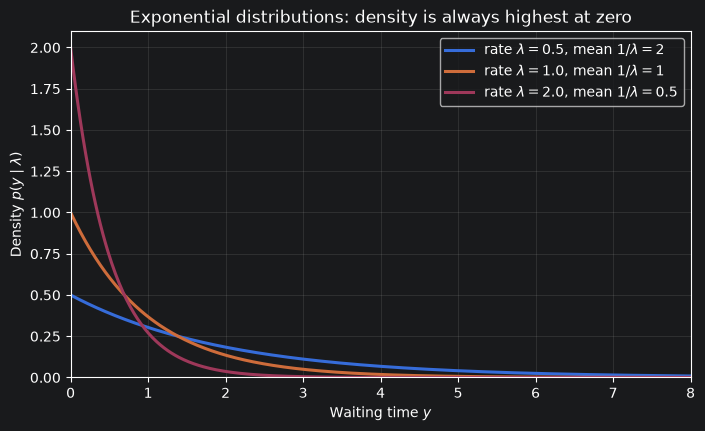

In [7]:
import numpy as np
import matplotlib.pyplot as plt

y = np.linspace(0.0, 8.0, 500)

fig, ax = plt.subplots(figsize=(8, 4.5))
for rate in [0.5, 1.0, 2.0]:
    density = rate * np.exp(-rate * y)
    ax.plot(y, density, linewidth=2.2,
            label=fr"rate $\lambda={rate}$, mean $1/\lambda={1/rate:g}$")

ax.set(
    title="Exponential distributions: density is always highest at zero",
    xlabel=r"Waiting time $y$",
    ylabel=r"Density $p(y\mid\lambda)$",
    xlim=(0, 8),
    ylim=(0, 2.1),
)
ax.legend()
ax.grid(alpha=0.2)
plt.show()


### 4.4 Gamma distribution: positive values with a peak away from zero

**Use when:** $y>0$ and positive observations cluster around a nonzero value rather than being most common near zero.

Imagine the total time required to complete several stages: registration, security, and boarding. Extremely short completion times are unlikely because every stage takes time. The observed durations may cluster around a positive value such as ten minutes.

A gamma distribution has two positive parameters:

- the **shape** $\alpha$ controls whether the curve decreases from zero or rises to a peak;
- the **rate** $\beta$ controls the time scale and horizontal compression.

Its density is

$$
p(y\mid\alpha,\beta)
=\frac{\beta^{\alpha}}{\Gamma(\alpha)}
y^{\alpha-1}\exp(-\beta y),
\qquad y>0.
$$

The gamma function $\Gamma(\alpha)$ is a normalization term. A beginner does not need to calculate it by hand.

The mean is

$$
\mathbb{E}[y]=\frac{\alpha}{\beta}.
$$

When $\alpha=1$, the gamma distribution becomes the exponential distribution. When $\alpha>1$, the density starts low, rises to a positive peak, and then decreases.

Taking the negative logarithm gives

$$
-\log p(y\mid\alpha,\beta)
=-\alpha\log\beta
+\log\Gamma(\alpha)
-(\alpha-1)\log y
+\beta y.
$$

The network can predict positive values $\alpha(x)$ and $\beta(x)$. The plot below fixes $\beta=1$ and shows how changing $\alpha$ changes the shape.


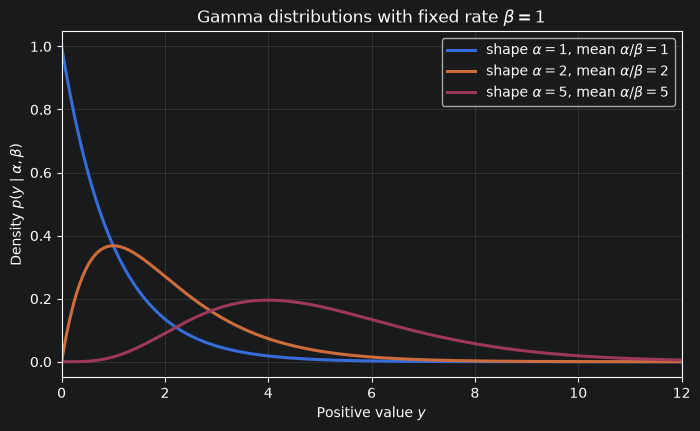

In [8]:
from math import gamma

import numpy as np
import matplotlib.pyplot as plt

y = np.linspace(0.001, 12.0, 600)
rate = 1.0

fig, ax = plt.subplots(figsize=(8, 4.5))
for shape in [1.0, 2.0, 5.0]:
    density = (
        rate**shape
        / gamma(shape)
        * y ** (shape - 1)
        * np.exp(-rate * y)
    )
    ax.plot(y, density, linewidth=2.2,
            label=fr"shape $\alpha={shape:g}$, mean $\alpha/\beta={shape:g}$")

ax.set(
    title=r"Gamma distributions with fixed rate $\beta=1$",
    xlabel=r"Positive value $y$",
    ylabel=r"Density $p(y\mid\alpha,\beta)$",
    xlim=(0, 12),
)
ax.legend()
ax.grid(alpha=0.2)
plt.show()


### 4.5 Exponential versus gamma with the same mean

Exponential and gamma distributions can have the same positive domain and the same mean while assigning density very differently.

Suppose both models have mean waiting time $10$:

- Exponential: $\lambda=0.1$, so $1/\lambda=10$.
- Gamma: $\alpha=10$ and $\beta=1$, so $\alpha/\beta=10$.

The exponential density is still highest at zero. It says an immediate event is most plausible, even though the average wait is ten.

The gamma density peaks near nine. It says waits near ten are common and near-zero waits are unlikely.

This is what **choose by shape** means: both distributions allow the same positive values, but they disagree about which positive values are plausible.

| Data pattern | Better starting choice |
|---|---|
| Most observations near zero, decreasing frequency afterward | Exponential |
| Observations cluster around a positive value | Gamma with $\alpha>1$ |
| Shape is uncertain | Compare candidate models using data and diagnostics |


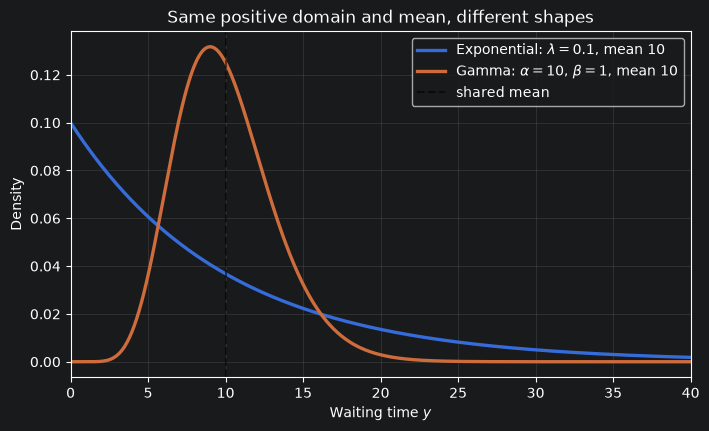

In [9]:
from math import gamma

import numpy as np
import matplotlib.pyplot as plt

y = np.linspace(0.001, 40.0, 800)

# Both distributions have mean 10.
exp_rate = 0.1
exp_density = exp_rate * np.exp(-exp_rate * y)

gamma_shape = 10.0
gamma_rate = 1.0
gamma_density = (
    gamma_rate**gamma_shape
    / gamma(gamma_shape)
    * y ** (gamma_shape - 1)
    * np.exp(-gamma_rate * y)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(y, exp_density, linewidth=2.4,
        label=r"Exponential: $\lambda=0.1$, mean $10$")
ax.plot(y, gamma_density, linewidth=2.4,
        label=r"Gamma: $\alpha=10$, $\beta=1$, mean $10$")
ax.axvline(10, color="black", linestyle="--", alpha=0.55, label="shared mean")
ax.set(
    title="Same positive domain and mean, different shapes",
    xlabel=r"Waiting time $y$",
    ylabel="Density",
    xlim=(0, 40),
)
ax.legend()
ax.grid(alpha=0.2)
plt.show()


### 4.6 Beta distribution: proportions between zero and one

**Use when:** $0<y<1$ represents a proportion, probability, or fraction.

With positive shape parameters $\alpha$ and $\beta$,

$$
p(y\mid\alpha,\beta)
=\frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}
y^{\alpha-1}(1-y)^{\beta-1}.
$$

The NLL is

$$
-\log p(y\mid\alpha,\beta)
=-\log\Gamma(\alpha+\beta)
+\log\Gamma(\alpha)
+\log\Gamma(\beta)
-(\alpha-1)\log y
-(\beta-1)\log(1-y).
$$

The network predicts two positive parameters. Together they control the center and concentration of the distribution.

Exact targets $0$ or $1$ require care because the standard beta density is defined on the open interval $(0,1)$.


### 4.7 von Mises distribution: circular directions

**Use when:** $y$ is an angle and values wrap around, such as wind direction.

Ordinary squared error is inappropriate near the wraparound. For example, angles just below $\pi$ and just above $-\pi$ are physically close even though their numerical difference is almost $2\pi$.

The von Mises density is

$$
p(y\mid\mu,\kappa)
=\frac{\exp[\kappa\cos(y-\mu)]}{2\pi I_0(\kappa)},
$$

where $\mu$ is the mean direction and $\kappa>0$ is concentration. Take the negative logarithm:

$$
-\log p(y\mid\mu,\kappa)
=-\kappa\cos(y-\mu)
+\log[2\pi I_0(\kappa)].
$$

If $\kappa$ is fixed, only the cosine term depends on the predicted direction. The resulting loss respects circular geometry.


## Topic 5 — Multimodal, multivariate, and ranking outputs


### 5.1 Gaussian mixture: several plausible real-valued answers

**Use when:** one input may have several genuinely plausible continuous targets.

A mixture with $M$ normal components is

$$
p(y\mid x)
=\sum_{m=1}^{M}\pi_m(x)
\mathcal{N}\left(y\mid\mu_m(x),\sigma_m^2(x)\right),
$$

where the weights satisfy $\pi_m\geq0$ and $\sum_m\pi_m=1$.

The network predicts:

- $M$ mixture logits, transformed by softmax into $\pi_m$;
- $M$ means $\mu_m$;
- $M$ positive scales $\sigma_m$.

The loss is

$$
\ell_{\text{mixture}}
=-\log\left[
\sum_{m=1}^{M}\pi_m
\mathcal{N}(y\mid\mu_m,\sigma_m^2)
\right].
$$

A critical point is

$$
\log(a+b)\neq\log a+\log b.
$$

Therefore, the logarithm cannot be moved through the mixture sum. In practice, this loss should be computed with a numerically stable log-sum-exp operation.


### 5.2 Multivariate normal: correlated real-valued outputs

**Use when:** $\mathbf{y}\in\mathbb{R}^D$ contains several continuous outputs whose residuals may remain correlated.

The distribution has mean vector $\boldsymbol{\mu}$ and covariance matrix $\Sigma$. Its NLL is

$$
-\log p(\mathbf{y}\mid\boldsymbol{\mu},\Sigma)
=\frac{D}{2}\log(2\pi)
+\frac{1}{2}\log|\Sigma|
+\frac{1}{2}(\mathbf{y}-\boldsymbol{\mu})^{T}
\Sigma^{-1}(\mathbf{y}-\boldsymbol{\mu}).
$$

The final term is a covariance-aware squared distance. Off-diagonal covariance entries describe relationships between output dimensions.

If $\Sigma=\sigma^2 I$ is fixed, the loss reduces to a scaled sum of squared errors. Predicting a full covariance is more expressive but requires a parameterization that guarantees a valid positive-definite matrix.


### 5.3 Plackett–Luce distribution: rankings

**Use when:** the target is an ordering of items rather than one class label.

Suppose the observed ranking is $\rho=(\rho_1,\ldots,\rho_K)$ and the network predicts a positive score $s_j$ for each item. Plackett–Luce constructs the ranking one position at a time:

$$
p(\rho\mid\mathbf{s})
=\prod_{r=1}^{K}
\frac{s_{\rho_r}}{\sum_{j\in R_r}s_j},
$$

where $R_r$ is the set of items still available at position $r$.

Take the negative logarithm:

$$
-\log p(\rho\mid\mathbf{s})
=\sum_{r=1}^{K}
\left[
\log\left(\sum_{j\in R_r}s_j\right)
-\log s_{\rho_r}
\right].
$$

At every ranking position, the loss rewards a high score for the selected item relative to all items that remain. This is more advanced than ordinary classification, but it follows the same recipe: define a distribution over legal targets and take its NLL.


## Topic 6 — How to make and check the choice


### 6.1 The same target domain can produce different losses

For a real-valued target, the domain alone does not choose the final loss:

| Assumption about residuals or outcomes | Distribution | Resulting loss behavior |
|---|---|---|
| Symmetric, ordinary noise | Normal | Squared residual |
| More frequent large residuals | Laplace | Absolute residual |
| Very heavy tails | Student's $t$ | Slowly growing robust penalty |
| Several plausible target regions | Gaussian mixture | Negative log of a weighted density sum |

The loss expresses what kinds of errors the model considers plausible. Choosing a loss is therefore equivalent to choosing assumptions about the output distribution.


### 6.2 Multiple outputs can use different distributions

Suppose one weather model predicts

$$
\mathbf{y}
=[\text{temperature},\text{rain},\text{wind direction},\text{pedestrian count}].
$$

A reasonable starting model might use:

| Component | Distribution | Component loss |
|---|---|---|
| Temperature | Normal | Gaussian NLL |
| Rain yes/no | Bernoulli | Binary cross-entropy |
| Wind direction | von Mises | Circular NLL |
| Pedestrian count | Poisson | Poisson NLL |

If the components are conditionally independent given the input, their likelihoods multiply and their NLL terms add:

$$
\mathcal{L}_i
=\ell_{i,\text{temperature}}
+\ell_{i,\text{rain}}
+\ell_{i,\text{direction}}
+\ell_{i,\text{count}}.
$$

One neural network can share hidden features while producing different parameter sets and different losses for each output component.


### 6.3 When may a term be removed from the loss?

During a derivation, a term may be removed from an optimization objective only when it does not depend on the parameters being optimized. A fixed positive scaling factor also leaves the location of the minimum unchanged.

Examples:

- In fixed-variance normal regression, $\frac{1}{2}\log(2\pi\sigma^2)$ is constant and may be removed.
- In Poisson regression, $\log(y!)$ depends on the observed target but not on the model, so it may be removed for optimization.
- In heteroscedastic normal regression, $\log\sigma_i^2$ cannot be removed because the network predicts $\sigma_i^2$.

Removing terms can preserve the optimizer while changing the numerical value and probabilistic interpretation of the loss. Keep the full NLL when calibrated likelihood values are important.


### 6.4 Distribution choice must be checked against data

A mathematically legal distribution can still be a poor model. After training, inspect whether its assumptions resemble the observed data.

Useful questions include:

- Do residuals look symmetric or strongly skewed?
- Are outliers much more common than the normal model predicts?
- Does uncertainty change with the input?
- Are there several plausible outputs for the same kind of input?
- For Poisson counts, is the variance much larger than the mean?
- Are predicted probabilities calibrated?
- Are multiple outputs still correlated after conditioning on $x$?

Validation performance, residual plots, calibration checks, and domain knowledge all help compare candidate distributions. Figure 5.11 provides a starting map, not a substitute for model checking.


### 6.5 Final checklist

Before choosing or deriving a loss, answer these questions:

1. What values can $y$ legally take?
2. Is $y$ continuous, discrete, circular, multivariate, or a ranking?
3. Should the distribution be symmetric, skewed, heavy-tailed, or multimodal?
4. Which distribution parameters must the network predict?
5. What constraints do those parameters have?
6. Which transforms enforce those constraints?
7. What is the likelihood $p(y\mid\theta)$?
8. What does $-\log p(y\mid\theta)$ become after applying log rules?
9. Which terms truly do not depend on the model parameters?
10. How will the distributional assumptions be checked after training?

The central principle is

> **Target domain chooses the family of valid distributions; modeling assumptions choose among those distributions; negative log-likelihood derives the loss.**
